In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

In [2]:
X_train, X_val, y_val = load_data()

In [3]:
print(X_train[:5])

[[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [4]:
print(X_val[:5])

[[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]]


In [5]:
print(y_val[:5])

[0 0 0 0 0]


In [6]:
print(X_train.shape)
print(X_val.shape)
print(y_val.shape)

(307, 2)
(307, 2)
(307,)


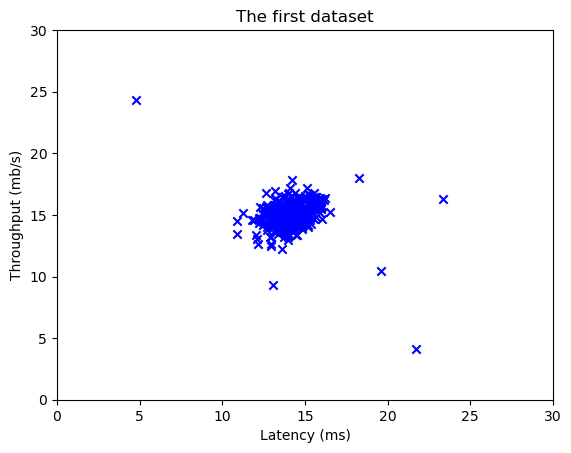

In [8]:
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 


plt.title("The first dataset")

plt.ylabel('Throughput (mb/s)')

plt.xlabel('Latency (ms)')

plt.axis([0, 30, 0, 30])
plt.show()

In [9]:
def estimate_gaussian(X):
    m, n = X.shape
    mu = np.mean(X,axis=0)
    var = np.var(X,axis=0)
    return mu, var

In [11]:
mu, var = estimate_gaussian(X_train)

print(mu)
print(var)


[14.11222578 14.99771051]
[1.83263141 1.70974533]


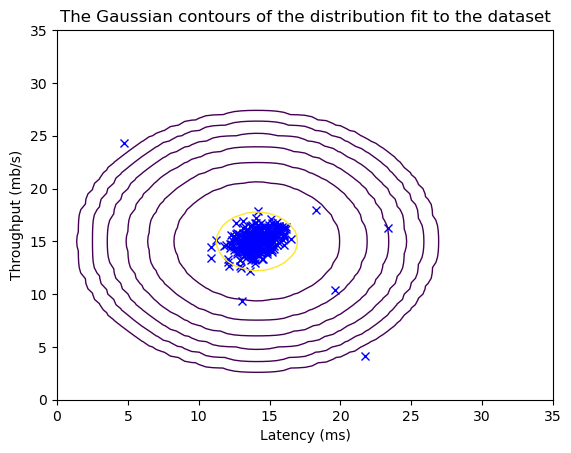

In [12]:
p = multivariate_gaussian(X_train, mu, var)

#Plotting code 
visualize_fit(X_train, mu, var)

In [13]:
def select_threshold(y_val,p_val):
    best_epsilon = 0
    best_F1 = 0
    F1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        predicitions = (p_val < epsilon)
        tp = np.sum((predicitions == 1) & (y_val == 1))
        fp = np.sum((predicitions == 1) & (y_val == 0))
        fn = np.sum((predicitions == 0) & (y_val == 1))
        if (tp + fp) > 0 and (tp + fn) > 0:
            prec = tp / (tp + fp)
            rec = tp / (tp + fn)
            F1 = (2 * prec * rec) / (prec + rec)
        else:
            F1 = 0

        if F1> best_F1:
            best_F1 = F1
            best_epsilon = epsilon
    return best_epsilon, best_F1

In [15]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('best epsilon:' , epsilon)
print('best F1: ', F1)

best epsilon: 8.990852779269495e-05
best F1:  0.8750000000000001


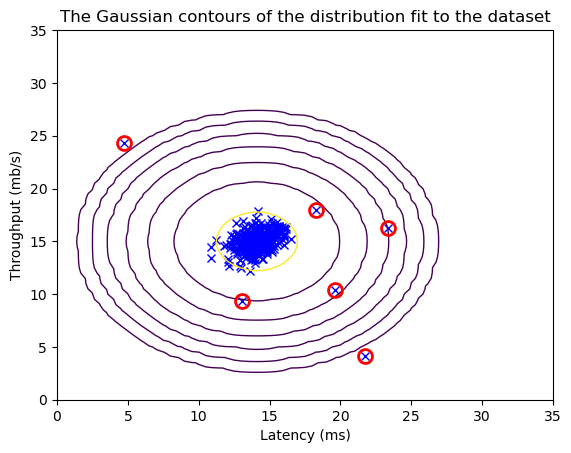

In [16]:

outliers = p < epsilon


visualize_fit(X_train, mu, var)


plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

In [21]:
#LARGE DATASET

In [17]:
X_train_high,X_val_high,y_val_high = load_data_multi()

In [18]:
print(X_train_high.shape)
print(X_val_high.shape)
print(y_val_high.shape)

(1000, 11)
(100, 11)
(100,)


In [20]:
# Estimate the Gaussian parameters
mu_high, var_high = estimate_gaussian(X_train_high)

# Evaluate the probabilites for the training set
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# Evaluate the probabilites for the cross validation set
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# Find the best threshold
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117
